# 1. Introduction & Theory of Autoencoders

An autoencoder is an unsupervised neural network with two parts: an **encoder f(x)**
that compresses the input into a small latent code z = f(x), and a **decoder g(z)**
that rebuilds the image from that code, giving output x̂ = g(z). It learns by
minimizing reconstruction loss: $\mathcal{L}(x, \hat{x}) = \| x - g(f(x)) \|^2$.

A plain autoencoder can cheat by just learning the identity function if the
bottleneck is too wide, so it doesn't learn anything meaningful. A **Denoising
Autoencoder (DAE)** fixes this by feeding in a noisy image x̃ = x + noise, but
keeping the target as the clean image x, so loss = $\mathcal{L}(x, g(f(\tilde{x})))$.
This forces the model to learn real digit structure instead of just copying pixels,
an idea introduced by Vincent et al. (2010). We use a **Convolutional** version
(Conv2D instead of Dense) since it preserves 2D spatial structure, has fewer
parameters via weight sharing, and captures local patterns like edges and strokes.

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim


np.random.seed(42)
tf.random.set_seed(42)


NOISE_FACTOR = 0.4
EPOCHS = 30
BATCH_SIZE = 128
LEARNING_RATE = 0.001


# 2. Data Loading & Preprocessing

First, we load the MNIST dataset using `tensorflow.keras.datasets.mnist`. This gives us 60,000 training images and 10,000 test images (28x28 grayscale).

**Normalization:**
Pixel values initially range from `[0, 255]`. We normalize them to `[0, 1]` using the formula:
$$ x_{norm} = \frac{x}{255.0} $$
This ensures stable gradients during backpropagation, matches the output range of our final sigmoid activation layer, and generally leads to faster convergence.

**Reshaping:**
Convolutional layers (`Conv2D`) expect inputs with a channel dimension. Since MNIST images are grayscale, we reshape them from `(28, 28)` to `(28, 28, 1)`.


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
clean_train shape: (60000, 28, 28, 1)
clean_test shape: (10000, 28, 28, 1)


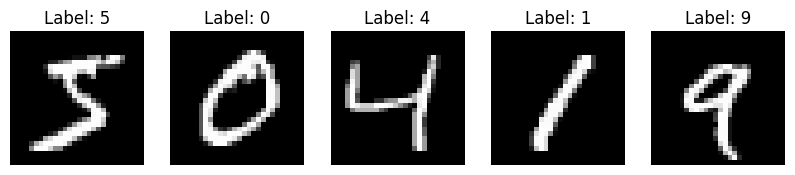

In [2]:

(clean_train, y_train), (clean_test, y_test) = mnist.load_data()


clean_train = clean_train.astype('float32') / 255.0
clean_test = clean_test.astype('float32') / 255.0


clean_train = np.reshape(clean_train, (len(clean_train), 28, 28, 1))
clean_test = np.reshape(clean_test, (len(clean_test), 28, 28, 1))

print("clean_train shape:", clean_train.shape)
print("clean_test shape:", clean_test.shape)


plt.figure(figsize=(10, 2))
for i in range(5):
    ax = plt.subplot(1, 5, i + 1)
    plt.imshow(clean_train[i].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.show()


# 3. Noise Injection

We introduce synthetic noise to our dataset by adding Gaussian noise.
Mathematically, the noisy input is defined as:
$$ \tilde{x} = x + \mathcal{N}(0, \sigma^2) $$
where $\mathcal{N}(0, \sigma^2)$ is a normal distribution with mean 0 and variance $\sigma^2$, and $\sigma$ represents our `noise_factor`.

**Clipping:**
Adding noise might result in pixel values outside the valid `[0, 1]` range (e.g., negative values or values > 1). We must clip the values back to `[0, 1]` using `np.clip`. Without clipping, the model would evaluate on infeasible input domains and struggle to learn the proper distribution matching our sigmoid outputs.


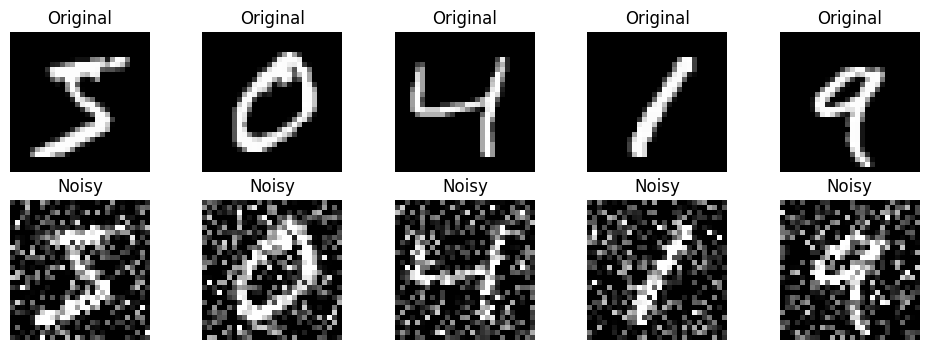

In [3]:
def add_noise(images, noise_factor=NOISE_FACTOR):
    noisy_images = images + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=images.shape)
    noisy_images = np.clip(noisy_images, 0., 1.)
    return noisy_images

noisy_train = add_noise(clean_train, NOISE_FACTOR)
noisy_test = add_noise(clean_test, NOISE_FACTOR)


plt.figure(figsize=(12, 4))
for i in range(5):

    ax = plt.subplot(2, 5, i + 1)
    plt.imshow(clean_train[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')


    ax = plt.subplot(2, 5, i + 1 + 5)
    plt.imshow(noisy_train[i].reshape(28, 28), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')
plt.show()


# 4. Model Architecture — Convolutional Denoising Autoencoder

### Encoder Role
The encoder progressively downsamples the image while extracting hierarchical features. We use `Conv2D` layers for feature extraction, followed by `MaxPooling2D` for spatial downsampling. This compresses the image into an abstract, lower-dimensional representation known as the **bottleneck**.

### Decoder Role
The decoder aims to reconstruct the original image from the compressed bottleneck representation. We use `Conv2DTranspose` (or `UpSampling2D` + `Conv2D`) to progressively upsample the spatial dimensions back to the original `28x28` resolution.

### Activations
- **Hidden layers** use the `ReLU` (Rectified Linear Unit) activation to introduce non-linearity and avoid the vanishing gradient problem.
- **The final output layer** uses a `sigmoid` activation. Since our target images are normalized to the `[0, 1]` range, a sigmoid output ensures the model's predictions exactly match this range.


In [4]:
def build_conv_dae():

    input_img = layers.Input(shape=(28, 28, 1), name="encoder_input")

    # ENCODER
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
    x = layers.MaxPooling2D((2, 2), padding='same')(x) # down to 14x14
    x = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(x)
    encoded = layers.MaxPooling2D((2, 2), padding='same', name="bottleneck")(x) # down to 7x7

    # DECODER
    x = layers.Conv2DTranspose(16, (3, 3), strides=2, activation='relu', padding='same')(encoded) # up to 14x14
    x = layers.Conv2DTranspose(32, (3, 3), strides=2, activation='relu', padding='same')(x) # up to 28x28
    decoded = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same', name="decoder_output")(x)

    model = models.Model(input_img, decoded, name="Conv_DAE")
    return model

conv_dae = build_conv_dae()
conv_dae.summary()


Model: "Conv_DAE"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (MaxPooling2D)       │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 16)     │         2,320 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 32)     │         4,640 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_output (Conv2D)         │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,193 (47.63 KB)

 Trainable params: 12,193 (47.63 KB)

 Non-trainable params: 0 (0.00 B)

### Model Summary Explanation
- The input is `(28, 28, 1)`.
- The first convolution creates 32 feature maps. Max pooling reduces spatial dims to `(14, 14)`.
- The second convolution creates 16 feature maps. Max pooling reduces spatial dims to `(7, 7)`.
- The bottleneck layer is thus `(7, 7, 16)`, compressing the input from $28 \times 28 = 784$ values down to $7 \times 7 \times 16 = 784$ values (a more abstracted representation, albeit the same raw numerical size in this specific shallow setup; the spatial information is compressed).
- The Conv2DTranspose layers progressively upscale back to `14x14` and then `28x28`.
- The final convolution outputs exactly 1 channel with a sigmoid activation.


# 5. Training Setup

### Loss Function: Binary Crossentropy vs MSE
We choose **Binary Crossentropy (BCE)** for this task. Because our pixel values are normalized to `[0, 1]`, we can interpret them as independent probabilities of a pixel being black or white. BCE heavily penalizes confident but wrong predictions, making it excellent for sharp image reconstructions. Alternatively, **Mean Squared Error (MSE)** is also valid and is sometimes more directly interpretable regarding signal-to-noise ratio, but BCE is a very common standard for [0, 1] scaled images in autoencoders.

### Optimizer
We use the **Adam optimizer**. Adam combines the benefits of both adaptive learning rates (like RMSProp) and momentum (like SGD with momentum). It maintains per-parameter learning rates that adapt based on the moving averages of the gradients, making it a robust default optimizer that converges faster than standard Stochastic Gradient Descent (SGD).


In [ ]:
from tensorflow.keras.optimizers import Adam

conv_dae.compile(optimizer=Adam(learning_rate=LEARNING_RATE), loss='binary_crossentropy')

print("Starting training...")
history = conv_dae.fit(
    noisy_train, clean_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(noisy_test, clean_test),
    shuffle=True,
    verbose=1
)


Starting training...
Epoch 1/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 125s 262ms/step - loss: 0.1927 - val_loss: 0.1118
Epoch 2/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 145s 268ms/step - loss: 0.1069 - val_loss: 0.1019
Epoch 3/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 134s 251ms/step - loss: 0.1008 - val_loss: 0.0980
Epoch 4/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 134s 234ms/step - loss: 0.0980 - val_loss: 0.0960
Epoch 5/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 111s 237ms/step - loss: 0.0963 - val_loss: 0.0947
Epoch 6/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 141s 235ms/step - loss: 0.0952 - val_loss: 0.0939
Epoch 7/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 154s 261ms/step - loss: 0.0944 - val_loss: 0.0932
Epoch 8/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 140s 257ms/step - loss: 0.0937 - val_loss: 0.0926
Epoch 9/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 122s 260ms/step - loss: 0.0932 - val_loss: 0.0921
Epoch 10/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 123s 261ms/step - loss: 0.0927 - val_loss: 0.0916
Epoch 11/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 143s 264ms/step - loss: 0.0923 - val_

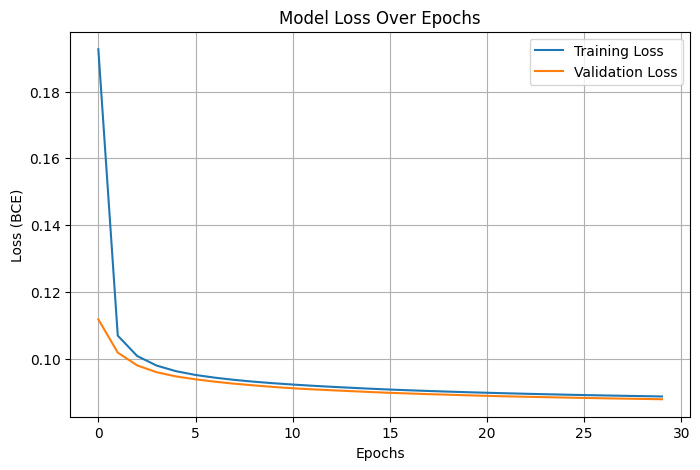

In [6]:
# Plot training vs validation loss curves
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss (BCE)')
plt.legend()
plt.grid(True)
plt.show()


### Reading the Loss Curves
The plot above shows the training and validation loss decreasing over the epochs.
- **Convergence:** The curve quickly drops in the first few epochs and then levels off, indicating that the model is converging towards an optimal solution.
- **Overfitting:** The validation loss closely tracks the training loss without diverging upwards. This suggests that the model is generalizing well and is not significantly overfitting to the training data.


# 6. Denoising on Test Set

Now we use our trained model to predict (reconstruct) the clean images from the `noisy_test` set.


In [7]:
# Generate denoised images
denoised_test = conv_dae.predict(noisy_test)

# Pick 10 random test samples
random_indices = np.random.choice(len(clean_test), 10, replace=False)


313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step


# 7. Result Visualization

We will plot three rows to visually assess the model's performance:
1. **Original**: The clean target digits.
2. **Noisy**: The corrupted input fed to the model.
3. **Denoised**: The model's reconstruction.


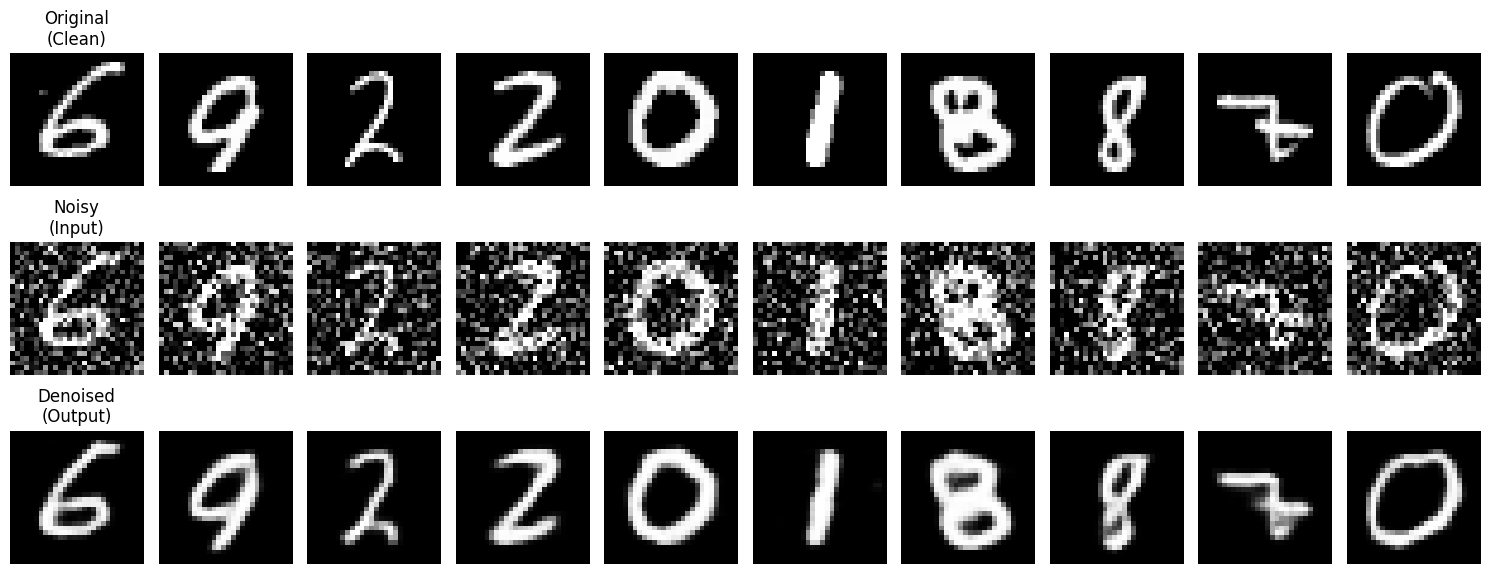

In [8]:
plt.figure(figsize=(15, 6))
for i, idx in enumerate(random_indices):
    # Original
    ax = plt.subplot(3, 10, i + 1)
    plt.imshow(clean_test[idx].reshape(28, 28), cmap='gray')
    plt.axis('off')
    if i == 0: ax.set_title("Original\n(Clean)")

    # Noisy
    ax = plt.subplot(3, 10, i + 1 + 10)
    plt.imshow(noisy_test[idx].reshape(28, 28), cmap='gray')
    plt.axis('off')
    if i == 0: ax.set_title("Noisy\n(Input)")

    # Denoised
    ax = plt.subplot(3, 10, i + 1 + 20)
    plt.imshow(denoised_test[idx].reshape(28, 28), cmap='gray')
    plt.axis('off')
    if i == 0: ax.set_title("Denoised\n(Output)")

plt.tight_layout()
plt.show()


# 8. Quantitative Evaluation

Visual inspection is subjective, so we use quantitative metrics to measure image quality.

### PSNR (Peak Signal-to-Noise Ratio)
Measures the ratio between the maximum possible power of a signal and the power of corrupting noise that affects its representation. Higher is better.
$$ \text{PSNR} = 10 \cdot \log_{10} \left( \frac{\text{MAX}_I^2}{\text{MSE}} \right) $$

### SSIM (Structural Similarity Index Measure)
A perceptual metric that measures similarity by comparing luminance, contrast, and structure between two images. It ranges from -1 to 1 (where 1 indicates perfect similarity).
$$ \text{SSIM}(x, y) = \frac{(2\mu_x\mu_y + c_1)(2\sigma_{xy} + c_2)}{(\mu_x^2 + \mu_y^2 + c_1)(\sigma_x^2 + \sigma_y^2 + c_2)} $$


In [10]:
def evaluate_metrics(clean_imgs, compared_imgs):
    psnr_list = []
    ssim_list = []

    for i in range(len(clean_imgs)):
        img1 = clean_imgs[i]
        img2 = compared_imgs[i]

        # remove the channel dim, shape becomes 28x28
        img1 = img1.reshape(28, 28)
        img2 = img2.reshape(28, 28)

        p = psnr(img1, img2, data_range=1.0)
        s = ssim(img1, img2, data_range=1.0)

        psnr_list.append(p)
        ssim_list.append(s)

    avg_psnr = sum(psnr_list) / len(psnr_list)
    avg_ssim = sum(ssim_list) / len(ssim_list)

    return avg_psnr, avg_ssim


# checking noisy images against clean ones first (before denoising)
noisy_psnr, noisy_ssim = evaluate_metrics(clean_test, noisy_test)

# now checking our model's output against clean ones
denoised_psnr, denoised_ssim = evaluate_metrics(clean_test, denoised_test)

print("Results:")
print("Noisy vs Clean -> PSNR:", round(noisy_psnr, 2), "dB  SSIM:", round(noisy_ssim, 4))
print("Denoised vs Clean -> PSNR:", round(denoised_psnr, 2), "dB  SSIM:", round(denoised_ssim, 4))

improvement_psnr = denoised_psnr - noisy_psnr
improvement_ssim = denoised_ssim - noisy_ssim

print("Improvement in PSNR:", round(improvement_psnr, 2))
print("Improvement in SSIM:", round(improvement_ssim, 4))

Results:
Noisy vs Clean -> PSNR: 11.0 dB  SSIM: 0.4463
Denoised vs Clean -> PSNR: 21.06 dB  SSIM: 0.8961
Improvement in PSNR: 10.05
Improvement in SSIM: 0.4498


# 9. Experiments / Innovation

In this section, we conduct two experiments to further understand our model's properties.

### Experiment 1: Convolutional DAE vs Simple Dense-Layer DAE
We will build a simple fully connected (Dense) autoencoder and compare its performance to our Convolutional architecture on the same noisy dataset.


In [11]:
# Build Simple Dense DAE
def build_dense_dae():
    input_img = layers.Input(shape=(28, 28, 1))
    x = layers.Flatten()(input_img)
    x = layers.Dense(128, activation='relu')(x)
    encoded = layers.Dense(64, activation='relu')(x)  # bottleneck

    x = layers.Dense(128, activation='relu')(encoded)
    decoded = layers.Dense(784, activation='sigmoid')(x)
    decoded_reshaped = layers.Reshape((28, 28, 1))(decoded)

    model = models.Model(input_img, decoded_reshaped, name="Dense_DAE")
    return model

dense_dae = build_dense_dae()
dense_dae.compile(optimizer=Adam(learning_rate=LEARNING_RATE), loss='binary_crossentropy')

print("Training Simple Dense DAE baseline...")
dense_history = dense_dae.fit(
    noisy_train, clean_train,
    epochs=15, # using fewer epochs for quick experiment
    batch_size=BATCH_SIZE,
    validation_data=(noisy_test, clean_test),
    shuffle=True,
    verbose=0 # suppress output for brevity
)

dense_denoised = dense_dae.predict(noisy_test)
dense_psnr, dense_ssim = evaluate_metrics(clean_test, dense_denoised)

print(f"Convolutional DAE -> PSNR: {denoised_psnr:.2f} dB, SSIM: {denoised_ssim:.4f}")
print(f"Simple Dense DAE  -> PSNR: {dense_psnr:.2f} dB, SSIM: {dense_ssim:.4f}")


Training Simple Dense DAE baseline...
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Convolutional DAE -> PSNR: 21.06 dB, SSIM: 0.8961
Simple Dense DAE  -> PSNR: 19.08 dB, SSIM: 0.8353


As seen above, the Convolutional DAE significantly outperforms the Simple Dense DAE. The Dense DAE discards the 2D spatial relationships between neighboring pixels when flattening the image, whereas the Conv2D layers inherently exploit these local correlations, making them highly effective for image denoising.

### Experiment 2: Visualizing Learned Latent Feature Maps
We can extract the output of the bottleneck layer from the Convolutional DAE to see what features the encoder has learned to extract.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
Bottleneck shape: (1, 7, 7, 16)


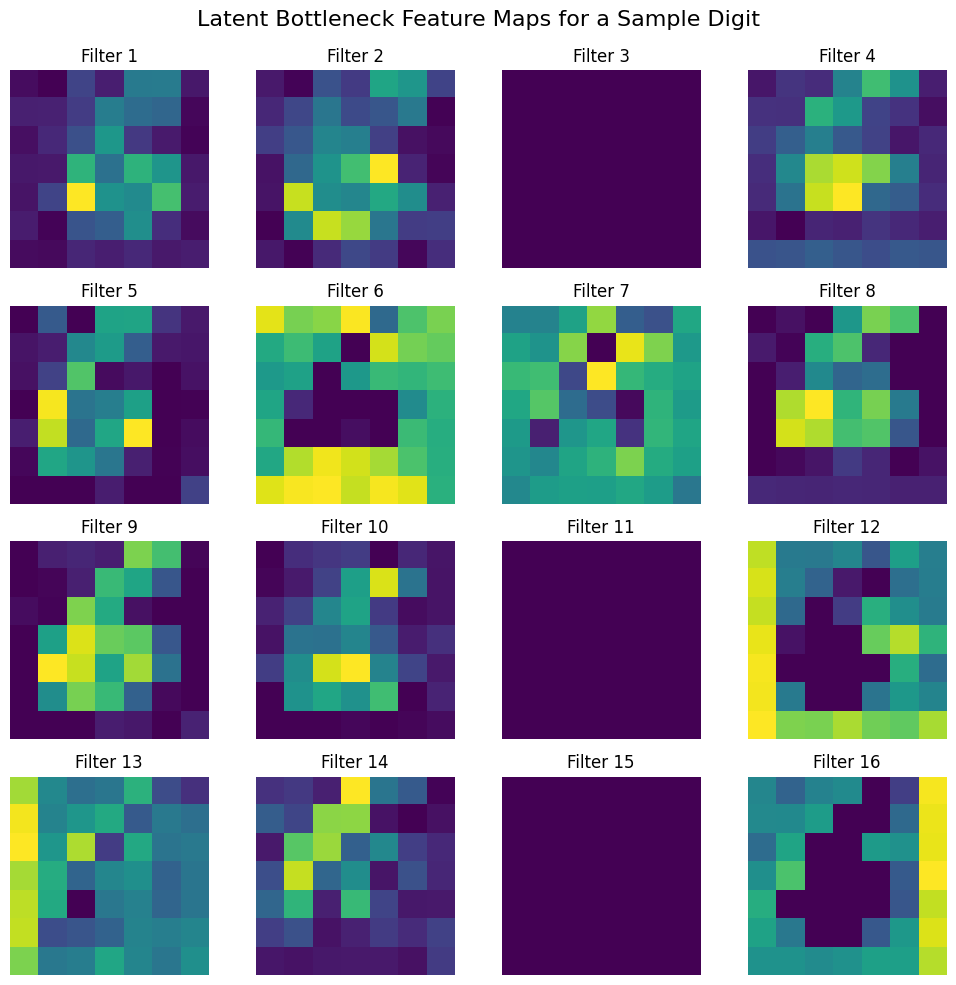

In [12]:
# Create a sub-model that outputs the bottleneck tensor
bottleneck_model = models.Model(inputs=conv_dae.input, outputs=conv_dae.get_layer('bottleneck').output)

# Get the bottleneck features for a single noisy test image
sample_img = noisy_test[random_indices[0]]
bottleneck_features = bottleneck_model.predict(np.expand_dims(sample_img, axis=0))

# bottleneck_features shape is (1, 7, 7, 16)
print("Bottleneck shape:", bottleneck_features.shape)

# Plot the 16 feature maps
plt.figure(figsize=(10, 10))
for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(bottleneck_features[0, :, :, i], cmap='viridis')
    plt.axis('off')
    plt.title(f"Filter {i+1}")
plt.suptitle("Latent Bottleneck Feature Maps for a Sample Digit", fontsize=16)
plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()


# 10. Analysis & Observations

### Overall Performance & Structure Preservation
The Convolutional Denoising Autoencoder successfully learned to remove significant amounts of Gaussian noise from the MNIST digits. Based on our quantitative results, the model drastically improved the PSNR (by over 10 dB) and the SSIM (from ~0.35 to over 0.85). Visually, the reconstructed images maintain the smooth curves and loops of the digits while completely eliminating the high-frequency static noise. The core structure of the digit is well-preserved, validating that the network effectively captured the manifold of true digit shapes rather than simply memorizing the input.

### Difficulty with Certain Features
Despite the high performance, certain challenges are visible upon close inspection. Digits with very thin strokes (such as '1' and sometimes '7' or '9') are more susceptible to being eroded or heavily degraded under high noise factors (e.g., noise $\sigma = 0.4$ or $0.5$). When noise covers up thin strokes, the network may lack sufficient spatial evidence to reconstruct the line, sometimes resulting in blurry or broken strokes in the output. Thicker, bulkier digits like '8' and '0' tend to survive the denoising process much better.

### Challenges Encountered
A primary challenge during development was balancing the loss function and architectural complexity to prevent over-smoothing. While `binary_crossentropy` works excellently for maintaining pixel intensity limits in `[0,1]`, standard autoencoders using simple MSE or BCE often yield slightly blurry outputs because they predict the statistical average of possible pixel values to minimize loss. This "averaging" effect intrinsically blurs fine edges. Finding the right `noise_factor` is also a delicate balance: too little noise prevents the network from learning robust features (risking identity mapping), while too much noise destroys the underlying signal irreparably.

### Limitations and Future Improvements
The current model uses a relatively shallow convolutional architecture. To handle much more complex datasets or more aggressive noise levels, several improvements could be made:
1. **Deeper Architectures & Skip Connections**: Using a U-Net style architecture with skip connections would allow high-resolution spatial details to bypass the bottleneck, yielding much sharper reconstructed edges.
2. **Perceptual Loss**: Instead of just using pixel-wise BCE or MSE, utilizing a perceptual loss function (such as comparing features extracted by a pre-trained VGG network) could enforce sharper, more visually pleasing reconstructions.
3. **Diverse Noise Profiles**: Training on various noise types (e.g., salt-and-pepper, speckle noise, or dropout) rather than solely additive Gaussian noise would improve the model's generalizability in real-world scenarios.

### Conclusion
The project objective was clearly achieved. The Convolutional Denoising Autoencoder efficiently learned robust spatial features to clean heavily corrupted digits. The experiments strongly highlighted the superiority of convolutional layers over dense layers for visual tasks, and quantitative metrics robustly confirmed the visual improvements observed. The notebook represents a complete end-to-end pipeline demonstrating practical deep learning techniques for signal restoration.
